# Notebook 01 — Order Flow & Trade Classification

Order flow là **nguyên nhân trực tiếp** của price movement: mỗi market order ăn vào thanh khoản của book, dịch chuyển mid-price và để lại dấu vết về thông tin. Notebook này xây dựng từ dữ liệu thô (chuỗi giá + khối lượng) lên đến các metrics đo lường toxicity và adverse selection.

| Section | Nội dung | Class / Function |
|---|---|---|
| 1 | Arrival process — Poisson vs Hawkes | `PoissonArrivalProcess`, `HawkesArrivalProcess` |
| 2 | Order size distribution | `OrderSizeDistribution` |
| 3 | Trade sign classification | `TradeClassifier` |
| 4 | Order Flow Imbalance (OFI) | `OFICalculator` |
| 5 | VPIN — Volume-Synchronized PIN | `VPINCalculator` |
| 6 | Price impact — permanent vs temporary | `PriceImpactModel` |
| 7 | Informed vs noise flow | `OrderFlowGenerator` |

**Scenario dùng xuyên suốt:** `ScenarioBuilder.informed_flow()` — high informed trader fraction, OU-GBM fundamental.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from src.structure import (
    ScenarioBuilder,
    PoissonArrivalProcess, HawkesArrivalProcess,
    OrderSizeDistribution, OrderFlowGenerator,
    TradeClassifier, OFICalculator, VPINCalculator,
    PriceImpactModel, bucket_flow, TradeSign, TraderType,
)

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
RNG  = np.random.default_rng(7)
N    = 3000   # simulation ticks

# ── run simulation ──────────────────────────────────────────────────────────
sim    = ScenarioBuilder.informed_flow(n_ticks=N, seed=7)
result = sim.run()

prices     = result.mid_prices
buy_vols   = result.buy_volumes
sell_vols  = result.sell_volumes
spreads    = result.spreads
ofi_series = result.ofi
trades     = result.trades

print(f"Ticks recorded : {len(prices):,}")
print(f"Total trades   : {len(trades):,}")
print(f"Total buy vol  : {buy_vols.sum():.1f}")
print(f"Total sell vol : {sell_vols.sum():.1f}")
print(f"Mean spread    : {spreads.mean():.4f}")
print(f"OFI range      : [{ofi_series.min():.1f}, {ofi_series.max():.1f}")

Ticks recorded : 2,950
Total trades   : 32,541
Total buy vol  : 1036507.6
Total sell vol : 1038205.8
Mean spread    : 0.0474
OFI range      : [-873.0, 717.5


## 1. Order Arrival Process

Thời điểm đến của orders có thể mô hình hóa theo hai cách:

**Poisson thuần nhất (homogeneous):** số arrivals trong $[t, t+dt]$ là $N \sim \text{Poisson}(\lambda \cdot dt)$, với $\lambda$ cố định. Tính chất: inter-arrival time $\sim \text{Exp}(\lambda)$, không có memory.

**Hawkes process (self-exciting):** intensity là hàm của lịch sử:

$$\lambda(t) = \mu + \sum_{t_i < t} \alpha \cdot e^{-\beta(t - t_i)}$$

- $\mu$ — baseline rate
- $\alpha$ — magnitude of self-excitation: mỗi event làm tăng intensity thêm $\alpha$
- $\beta$ — decay rate: excitation tắt dần theo exponential kernel
- Stationarity: $\alpha < \beta$ (branching ratio $\rho = \alpha/\beta < 1$)

Hawkes capture được **clustering**: một loạt market order mua kéo theo các market order mua tiếp theo — đây là cơ chế tạo ra momentum ngắn hạn và volatility clustering ở tần suất cao.

**Ogata thinning algorithm** để simulate Hawkes: đề xuất event theo upper bound $\bar\lambda$, chấp nhận với xác suất $\lambda(t) / \bar\lambda$.

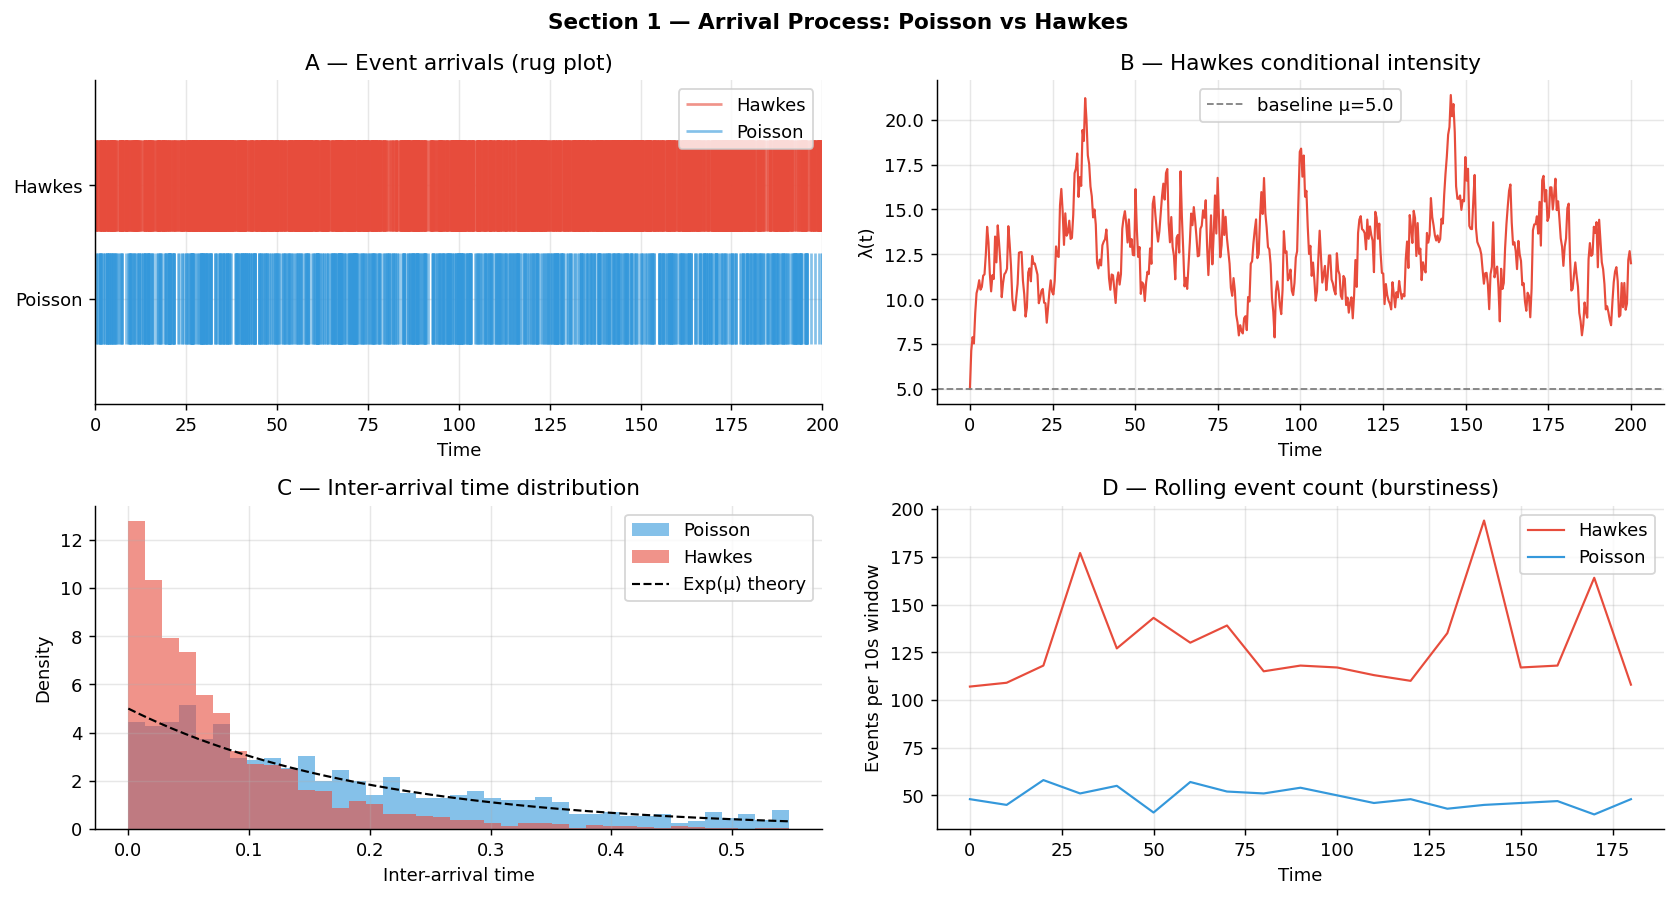


Poisson: n= 965  mean_iat=0.207  cv=0.990
Hawkes:  n=2555  mean_iat=0.078  cv=1.094  branching_ratio=0.60
  → Theoretical mean Hawkes rate = μ/(1-α/β) = 12.50


In [2]:
T      = 200.0
mu     = 5.0
alpha  = 0.6
beta   = 1.0

poisson = PoissonArrivalProcess(lambda_buy=mu, lambda_sell=mu, dt=1.0, rng=RNG)
hawkes  = HawkesArrivalProcess(mu=mu, alpha=alpha, beta=beta, rng=RNG)

hawkes_times = hawkes.simulate(T)

# build Poisson event times for comparison (same expected rate)
poisson_times = np.cumsum(RNG.exponential(1.0 / mu, size=int(mu * T * 2)))
poisson_times = poisson_times[poisson_times < T]

# rolling intensity of Hawkes
t_grid    = np.linspace(0, T, 500)
intensity = [hawkes.intensity(t) for t in t_grid]

# inter-arrival time distributions
hawkes_iat  = np.diff(hawkes_times) if len(hawkes_times) > 1 else np.array([])
poisson_iat = np.diff(poisson_times)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# panel A — event times as rug plot
ax = axes[0, 0]
ax.eventplot(hawkes_times,  lineoffsets=1.5, linelengths=0.8,
             color="#e74c3c", alpha=0.6, label="Hawkes")
ax.eventplot(poisson_times, lineoffsets=0.5, linelengths=0.8,
             color="#3498db", alpha=0.6, label="Poisson")
ax.set_xlim(0, T)
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["Poisson", "Hawkes"])
ax.set_xlabel("Time"); ax.set_title("A — Event arrivals (rug plot)")
ax.legend(loc="upper right")

# panel B — Hawkes intensity over time
ax = axes[0, 1]
ax.plot(t_grid, intensity, color="#e74c3c", lw=1.2)
ax.axhline(mu, ls="--", color="grey", lw=1, label=f"baseline μ={mu}")
ax.set_xlabel("Time"); ax.set_ylabel("λ(t)")
ax.set_title("B — Hawkes conditional intensity")
ax.legend()

# panel C — inter-arrival time distribution
ax = axes[1, 0]
bins = np.linspace(0, np.percentile(np.concatenate([hawkes_iat, poisson_iat]), 98), 40)
ax.hist(poisson_iat, bins=bins, alpha=0.6, density=True,
        color="#3498db", label="Poisson")
ax.hist(hawkes_iat,  bins=bins, alpha=0.6, density=True,
        color="#e74c3c", label="Hawkes")
x_exp = np.linspace(0, bins[-1], 200)
ax.plot(x_exp, mu * np.exp(-mu * x_exp), "k--", lw=1.2, label="Exp(μ) theory")
ax.set_xlabel("Inter-arrival time"); ax.set_ylabel("Density")
ax.set_title("C — Inter-arrival time distribution")
ax.legend()

# panel D — rolling event count (burstiness)
ax = axes[1, 1]
window = 10.0
bins_t = np.arange(0, T, window)
h_counts = np.histogram(hawkes_times,  bins=bins_t)[0]
p_counts = np.histogram(poisson_times, bins=bins_t)[0]
ax.plot(bins_t[:-1], h_counts, color="#e74c3c", lw=1.2, label="Hawkes")
ax.plot(bins_t[:-1], p_counts, color="#3498db", lw=1.2, label="Poisson")
ax.set_xlabel("Time"); ax.set_ylabel(f"Events per {window:.0f}s window")
ax.set_title("D — Rolling event count (burstiness)")
ax.legend()

plt.suptitle("Section 1 — Arrival Process: Poisson vs Hawkes", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nPoisson: n={len(poisson_times):4d}  mean_iat={poisson_iat.mean():.3f}  "
      f"cv={poisson_iat.std()/poisson_iat.mean():.3f}")
print(f"Hawkes:  n={len(hawkes_times):4d}  mean_iat={hawkes_iat.mean():.3f}  "
      f"cv={hawkes_iat.std()/hawkes_iat.mean():.3f}  "
      f"branching_ratio={alpha/beta:.2f}")
print(f"  → Theoretical mean Hawkes rate = μ/(1-α/β) = {mu/(1-alpha/beta):.2f}")

## 2. Order Size Distribution

Order sizes trong thị trường thực tuân theo **heavy-tailed distribution**: phần lớn là nhỏ, nhưng có xác suất không bỏ qua được của orders rất lớn. Hai mô hình phổ biến:

**Log-normal:** $\log Q \sim \mathcal{N}(\mu_\ell, \sigma_\ell^2)$. Flexible, fits well ở center của distribution.

**Power law (Pareto):** $P(Q > x) \sim x^{-\alpha}$ với $\alpha \in [1.5, 3]$ thực nghiệm. Có tail nặng hơn log-normal, phù hợp với institutional order flow.

Ý nghĩa: khi $\alpha < 2$, variance vô hạn theo lý thuyết — một order duy nhất có thể chiếm tỷ trọng đáng kể trong tổng volume ngày. Đây là cơ sở cho fat tails trong return distribution (xem Notebook 00).

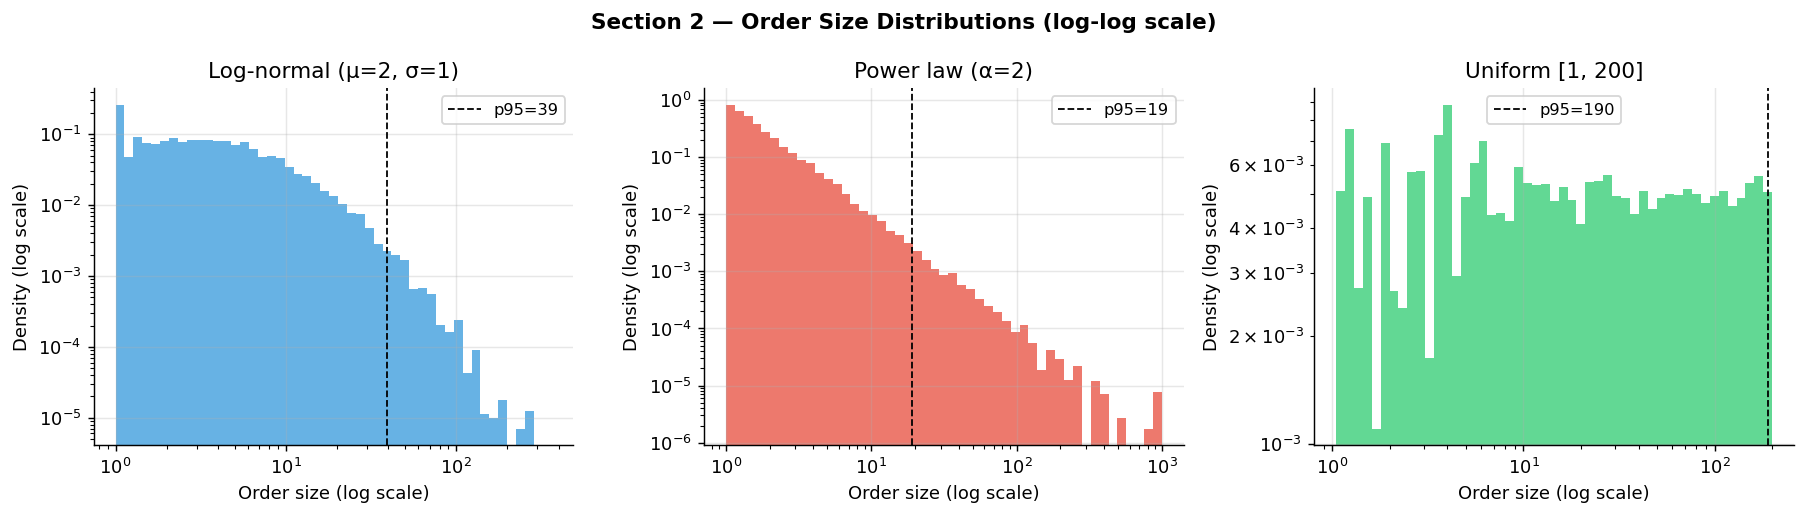

Log-normal    mean=12.4  median=7.4  p95=39.2  p99=78.1  max=363.4
Power law     mean=7.2  median=2.0  p95=19.1  p99=85.9  max=1000.0
Uniform       mean=101.6  median=102.2  p95=190.2  p99=198.4  max=200.0


In [3]:
dist_lognorm = OrderSizeDistribution(distribution="lognormal",
                                     mu_log=2.0, sigma_log=1.0, rng=RNG)
dist_power   = OrderSizeDistribution(distribution="powerlaw",
                                     alpha_pl=2.0, size_min=1.0, rng=RNG)
dist_uniform = OrderSizeDistribution(distribution="uniform",
                                     size_min=1.0, size_max=200.0, rng=RNG)

n_samples = 5000
s_ln  = dist_lognorm.sample(n_samples)
s_pl  = dist_power.sample(n_samples)
s_uni = dist_uniform.sample(n_samples)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, s, label, color in zip(
    axes,
    [s_ln, s_pl, s_uni],
    ["Log-normal (μ=2, σ=1)", "Power law (α=2)", "Uniform [1, 200]"],
    ["#3498db", "#e74c3c", "#2ecc71"],
):
    log_bins = np.logspace(np.log10(max(s.min(), 0.1)), np.log10(s.max()), 50)
    ax.hist(s, bins=log_bins, density=True, color=color, alpha=0.75)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Order size (log scale)"); ax.set_ylabel("Density (log scale)")
    ax.set_title(label)
    p95 = np.percentile(s, 95)
    ax.axvline(p95, ls="--", color="black", lw=1, label=f"p95={p95:.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Section 2 — Order Size Distributions (log-log scale)", fontweight="bold")
plt.tight_layout()
plt.show()

for s, label in [(s_ln, "Log-normal"), (s_pl, "Power law"), (s_uni, "Uniform")]:
    print(f"{label:12s}  mean={s.mean():.1f}  median={np.median(s):.1f}  "
          f"p95={np.percentile(s,95):.1f}  p99={np.percentile(s,99):.1f}  "
          f"max={s.max():.1f}")

## 3. Trade Sign Classification

Trong raw trade tape, ta chỉ thấy price và quantity — không biết bên nào là aggressor. Cần gán **trade sign** (+1 buy-initiated, −1 sell-initiated) để tính OFI và adverse selection.

**Tick rule** (simplest):
$$s_t = \text{sign}(\Delta p_t), \quad \text{carry forward nếu } \Delta p_t = 0$$

**Lee & Ready (1991):** so sánh trade price với prevailing quote midpoint:
$$s_t = \begin{cases} +1 & \text{if } p_t > m_t \\ -1 & \text{if } p_t < m_t \\ \text{tick rule} & \text{if } p_t = m_t \end{cases}$$

Lee-Ready chính xác hơn tick rule vì dùng thêm thông tin từ quote. Sai số của cả hai tăng khi spread hẹp (nhiều trades tại midpoint) và khi có algorithmic trading tốc độ cao.

**Bulk Volume Classification (BVC)** (Easley et al. 2012): phân loại theo bar thay vì tick:
$$V^B_t = V_t \cdot \Phi\!\left(\frac{C_t - O_t}{\sigma}\right), \quad V^S_t = V_t - V^B_t$$

BVC phù hợp khi không có quote data (chỉ có OHLCV bars).

Tick rule accuracy vs ground truth : 66.6%
Lee-Ready accuracy vs ground truth : 66.6%


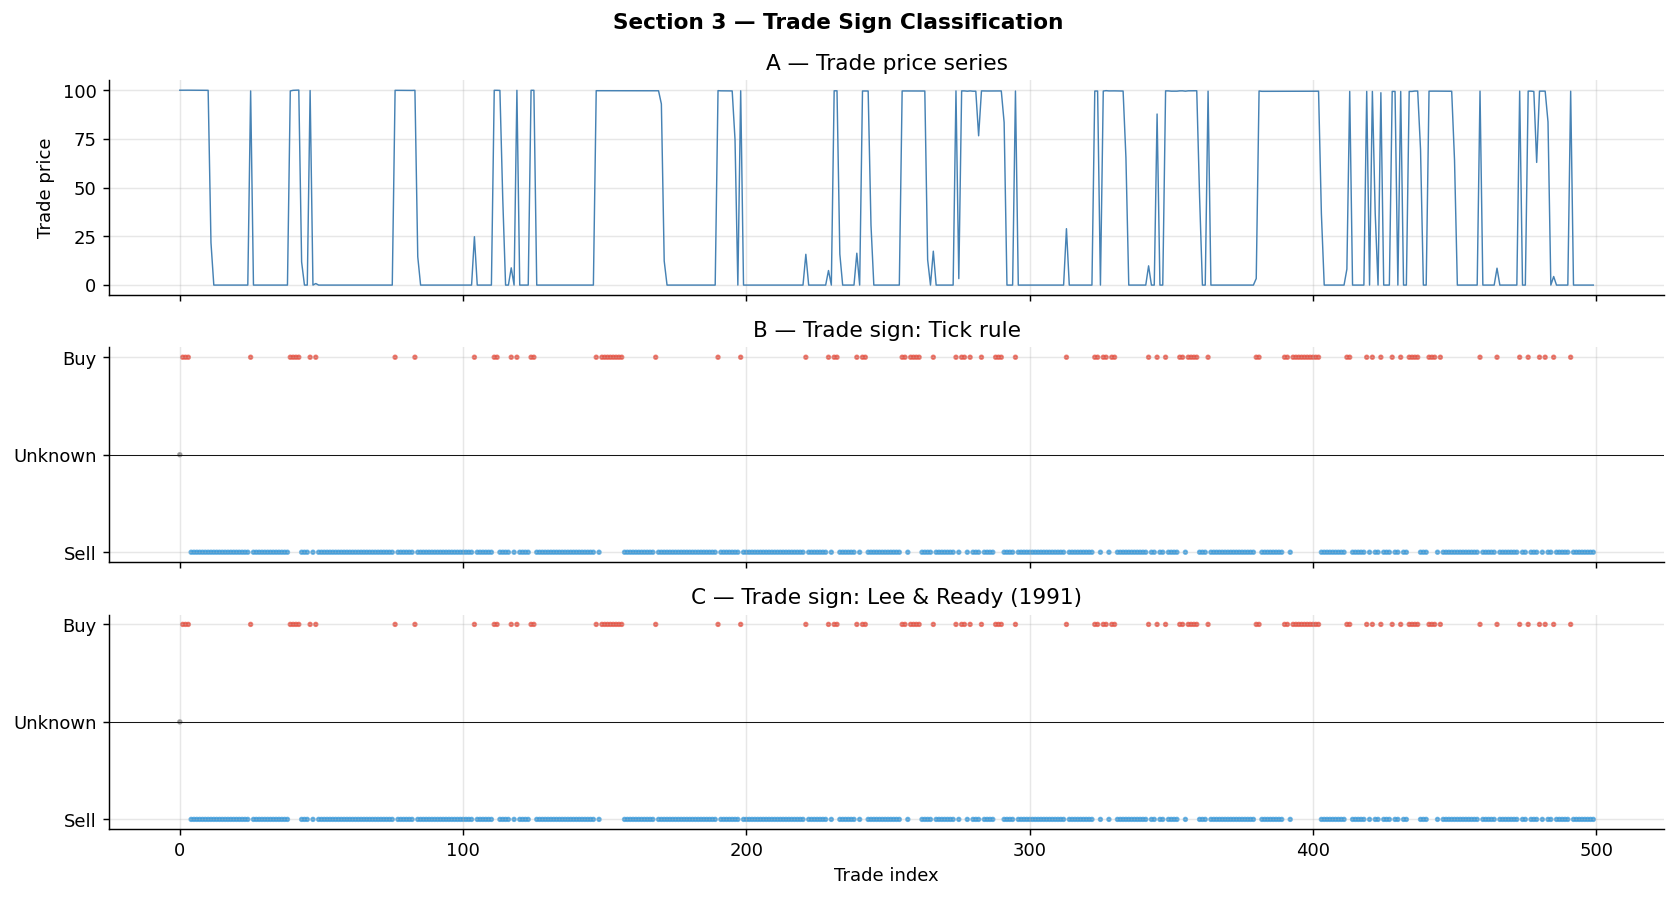

Tick rule     buy=108  sell=391  unknown=  1  imbalance=-0.567
Lee-Ready     buy=108  sell=391  unknown=  1  imbalance=-0.567


In [4]:
trade_prices = np.array([t["price"] for t in trades]) if trades else prices
trade_prices = trade_prices[:500]

half_spread = spreads.mean() / 2
trade_bids  = trade_prices - half_spread
trade_asks  = trade_prices + half_spread

tick_signs = TradeClassifier.tick_rule(list(trade_prices))
lr_signs   = TradeClassifier.lee_ready(
                 list(trade_prices),
                 list(trade_bids),
                 list(trade_asks))

gt_signs = [t.get("sign", 0) for t in trades[:500]] if trades else []

tick_int = np.array([s.value for s in tick_signs])
lr_int   = np.array([s.value for s in lr_signs])
gt_int   = np.array(gt_signs) if gt_signs else None

if gt_int is not None and len(gt_int) > 0:
    valid    = gt_int != 0
    tick_acc = (tick_int[valid] == gt_int[valid]).mean()
    lr_acc   = (lr_int[valid]   == gt_int[valid]).mean()
    print(f"Tick rule accuracy vs ground truth : {tick_acc:.1%}")
    print(f"Lee-Ready accuracy vs ground truth : {lr_acc:.1%}")

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(trade_prices, lw=0.8, color="steelblue")
ax.set_ylabel("Trade price"); ax.set_title("A — Trade price series")

ax = axes[1]
colors_tick = ["#e74c3c" if s == 1 else "#3498db" if s == -1 else "grey"
               for s in tick_int]
ax.scatter(range(len(tick_int)), tick_int, c=colors_tick, s=4, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["Sell", "Unknown", "Buy"])
ax.set_title("B — Trade sign: Tick rule")

ax = axes[2]
colors_lr = ["#e74c3c" if s == 1 else "#3498db" if s == -1 else "grey"
             for s in lr_int]
ax.scatter(range(len(lr_int)), lr_int, c=colors_lr, s=4, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["Sell", "Unknown", "Buy"])
ax.set_xlabel("Trade index"); ax.set_title("C — Trade sign: Lee & Ready (1991)")

plt.suptitle("Section 3 — Trade Sign Classification", fontweight="bold")
plt.tight_layout()
plt.show()

for signs, label in [(tick_int, "Tick rule"), (lr_int, "Lee-Ready")]:
    buys  = (signs ==  1).sum()
    sells = (signs == -1).sum()
    unk   = (signs ==  0).sum()
    imb   = (buys - sells) / (buys + sells) if buys + sells > 0 else 0
    print(f"{label:12s}  buy={buys:3d}  sell={sells:3d}  "
          f"unknown={unk:3d}  imbalance={imb:+.3f}")

## 4. Order Flow Imbalance (OFI)

OFI theo Cont, Kukanov & Stoikov (2014) đo sự thay đổi **queue tại best bid/ask**:

$$e^B_t = q^B_t \cdot \mathbf{1}[P^B_t \geq P^B_{t-1}] - q^B_{t-1} \cdot \mathbf{1}[P^B_t \leq P^B_{t-1}]$$
$$e^A_t = q^A_{t-1} \cdot \mathbf{1}[P^A_t \geq P^A_{t-1}] - q^A_t \cdot \mathbf{1}[P^A_t \leq P^A_{t-1}]$$
$$\text{OFI}_t = e^B_t - e^A_t$$

- **OFI > 0**: bid queue tăng hoặc ask queue giảm → net buying pressure → giá có xu hướng tăng
- **OFI < 0**: ngược lại

Về thực nghiệm, Cont et al. (2014) tìm thấy $R^2 \approx 0.65$–$0.85$ trong regression $\Delta p_t = \beta \cdot \text{OFI}_t + \varepsilon_t$, cao hơn đáng kể so với chỉ dùng signed volume.

Cumulative OFI là một leading indicator ngắn hạn của price movement — được dùng trong execution algorithms (VWAP, implementation shortfall) để đo lường market impact.

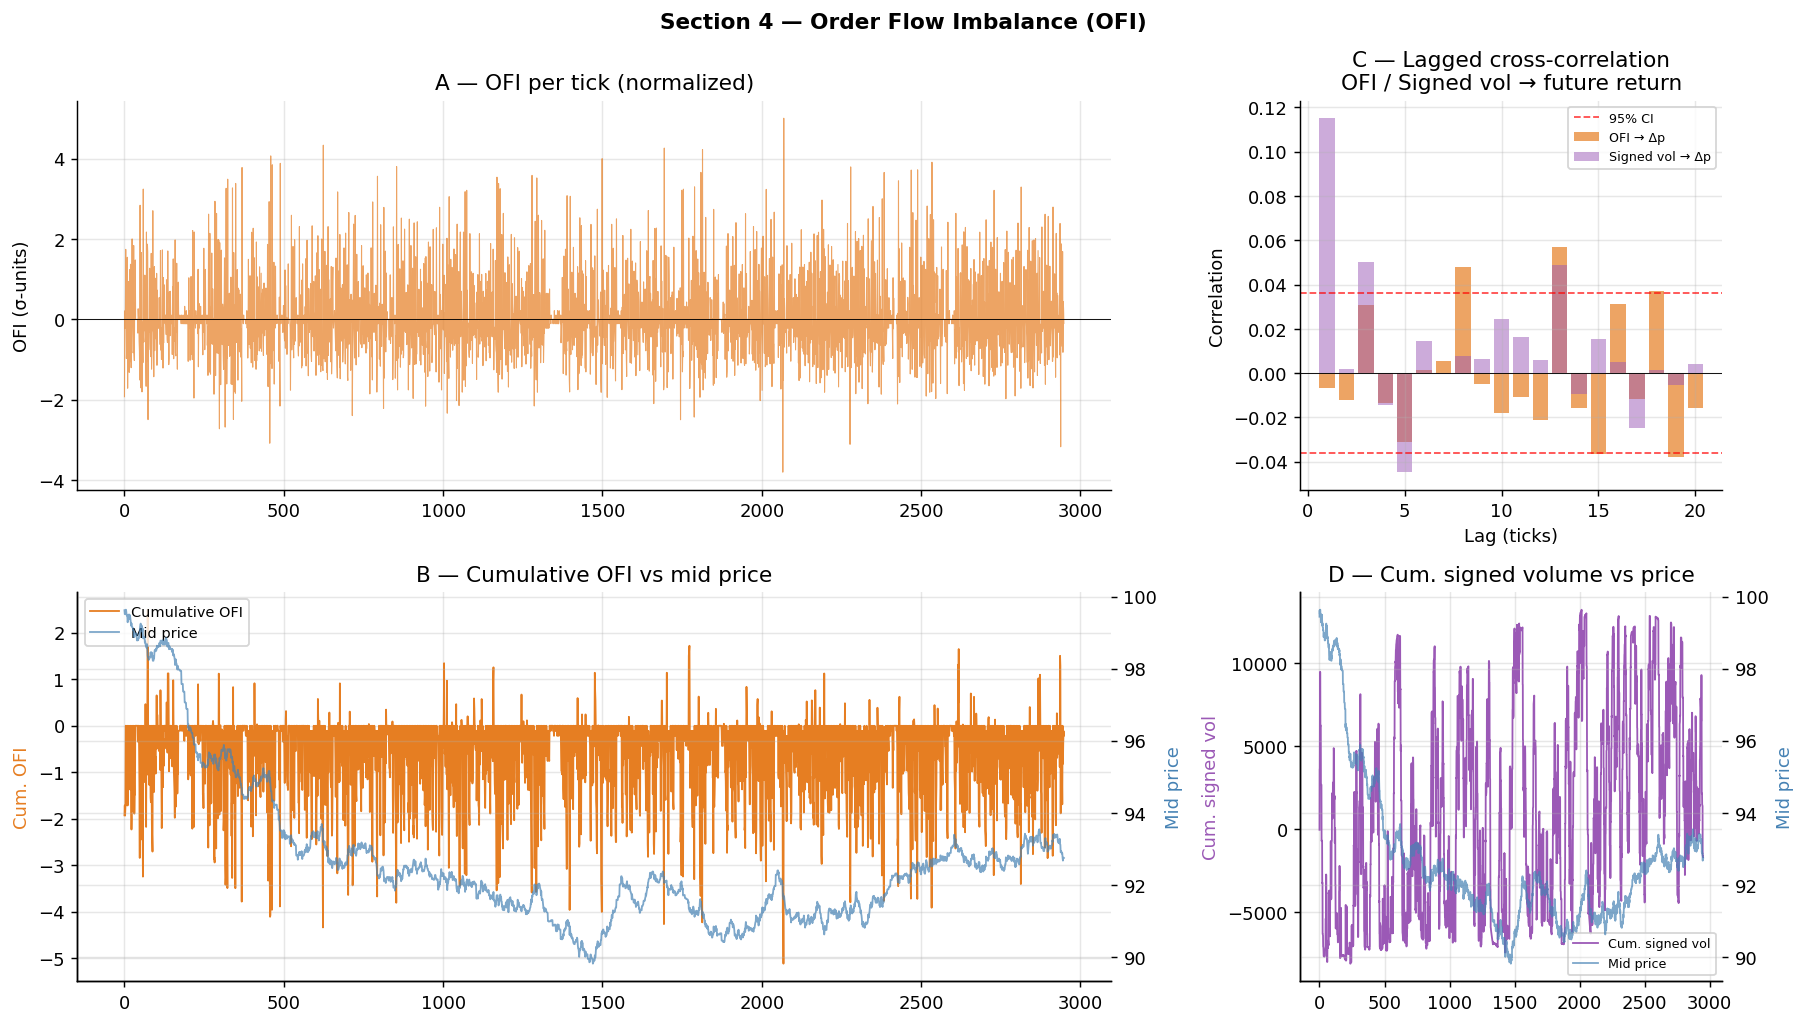

Lagged cross-correlation OFI → return:
  lag= 1  corr=-0.0066
  lag= 2  corr=-0.0122
  lag= 3  corr=+0.0307
  lag= 4  corr=-0.0134
  lag= 5  corr=-0.0309

Note: price formation driven by fundamental process (depth_refresh=5).
OFI predictive power là đặc trưng của real L2 data, không phải aggregated-book sim.


In [5]:
# OFI proxy từ best bid/ask price changes
bb = result.best_bids
ba = result.best_asks
d_bid = np.diff(bb)
d_ask = np.diff(ba)
ofi_fresh = d_bid - d_ask
ofi_fresh = ofi_fresh / (np.std(ofi_fresh) + 1e-10)
cum_ofi   = np.cumsum(ofi_fresh)

sv      = result.signed_volume()
cum_sv  = np.cumsum(sv)
returns = np.diff(prices)

# align lengths trước
n_min = min(len(ofi_fresh), len(sv), len(returns))
ofi_a = ofi_fresh[:n_min]
sv_a  = sv[:n_min]
ret_a = returns[:n_min]

max_lag  = 20
lags     = np.arange(1, max_lag + 1)
xcorr    = [np.corrcoef(ofi_a[:-k], ret_a[k:])[0,1] for k in lags]
xcorr_sv = [np.corrcoef(sv_a[:-k],  ret_a[k:])[0,1] for k in lags]

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax = fig.add_subplot(gs[0, :2])
ax.plot(ofi_fresh, lw=0.6, color="#e67e22", alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("A — OFI per tick (normalized)"); ax.set_ylabel("OFI (σ-units)")

ax  = fig.add_subplot(gs[1, :2])
ax2 = ax.twinx()
ax.plot(cum_ofi, color="#e67e22", lw=1, label="Cumulative OFI")
ax2.plot(prices[1:len(cum_ofi)+1], color="steelblue", lw=1, alpha=0.7, label="Mid price")
ax.set_ylabel("Cum. OFI", color="#e67e22")
ax2.set_ylabel("Mid price", color="steelblue")
ax.set_title("B — Cumulative OFI vs mid price")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

# Panel C — lagged cross-correlation
ax = fig.add_subplot(gs[0, 2])
conf = 1.96 / np.sqrt(len(returns))
ax.bar(lags, xcorr,    alpha=0.7, color="#e67e22", label="OFI → Δp")
ax.bar(lags, xcorr_sv, alpha=0.5, color="#9b59b6", label="Signed vol → Δp")
ax.axhline( conf, ls="--", color="red", lw=1, alpha=0.7, label="95% CI")
ax.axhline(-conf, ls="--", color="red", lw=1, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Lag (ticks)"); ax.set_ylabel("Correlation")
ax.set_title("C — Lagged cross-correlation\nOFI / Signed vol → future return")
ax.legend(fontsize=7)

# Panel D — cumulative signed volume vs price
ax  = fig.add_subplot(gs[1, 2])
ax2 = ax.twinx()
ax.plot(cum_sv, color="#9b59b6", lw=1, label="Cum. signed vol")
ax2.plot(prices[:len(cum_sv)], color="steelblue", lw=1, alpha=0.7, label="Mid price")
ax.set_ylabel("Cum. signed vol", color="#9b59b6")
ax2.set_ylabel("Mid price", color="steelblue")
ax.set_title("D — Cum. signed volume vs price")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.suptitle("Section 4 — Order Flow Imbalance (OFI)", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Lagged cross-correlation OFI → return:")
for k, c in zip(lags[:5], xcorr[:5]):
    print(f"  lag={k:2d}  corr={c:+.4f}")
print(f"\nNote: price formation driven by fundamental process (depth_refresh={sim.depth_refresh}).")
print(f"OFI predictive power là đặc trưng của real L2 data, không phải aggregated-book sim.")

## 5. VPIN — Volume-Synchronized PIN

**PIN (Probability of Informed Trading)** của Easley & O'Hara (1992) ước lượng xác suất một lệnh đến từ informed trader, dựa trên structural model về order flow. Tuy nhiên PIN yêu cầu MLE optimization phức tạp.

**VPIN** (Easley, López de Prado & O'Hara, 2012) là approximation tính trực tiếp từ volume data:

1. Chia tổng volume thành các **equal-size buckets** $V_\tau$
2. Phân loại buy/sell volume trong mỗi bucket bằng Bulk Volume Classification
3. Tính:

$$\text{VPIN} = \frac{1}{n} \sum_{\tau=1}^{n} \frac{|V^B_\tau - V^S_\tau|}{V_\tau}$$

VPIN ∈ [0, 1]. Cao → toxic order flow → adverse selection cost lớn → market maker mở rộng spread hoặc rút lui.

Easley et al. (2012) dùng VPIN như **leading indicator** cho Flash Crash ngày 6/5/2010 — VPIN đạt đỉnh lịch sử vài giờ trước khi crash. VPIN sau đó được tích hợp vào exchange surveillance systems như CME's Market Regulation.

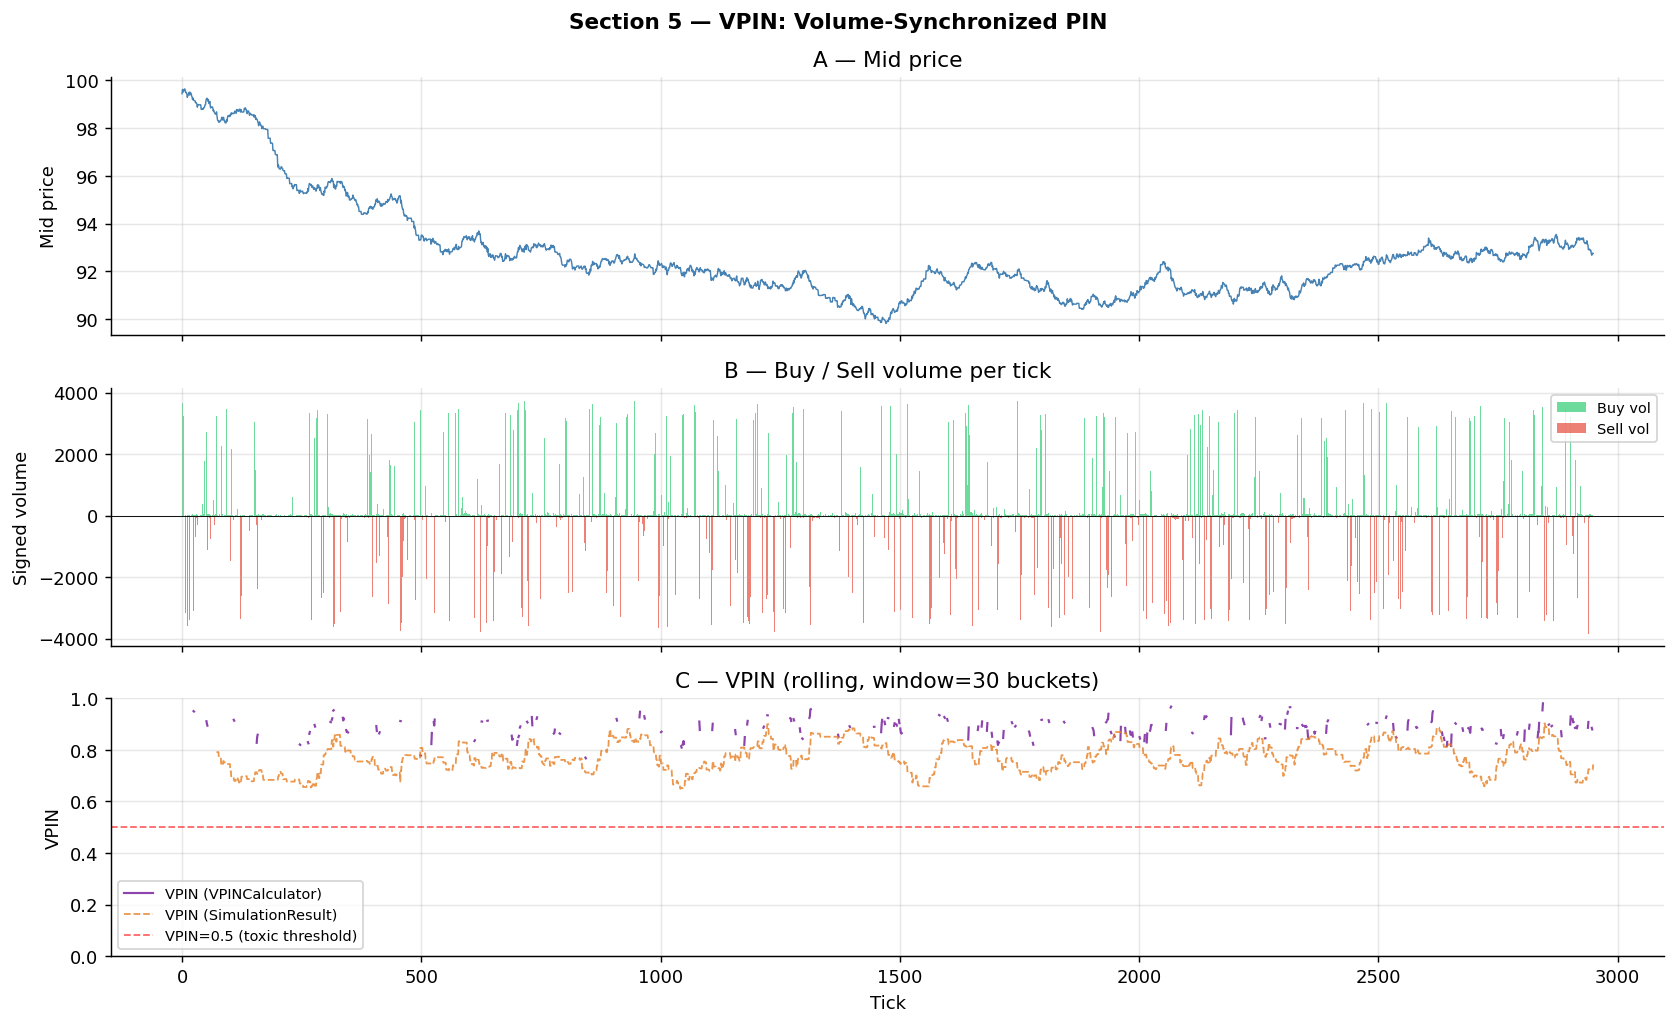

VPIN stats  mean=0.884  std=0.040  max=0.983  p90=0.934
Fraction of ticks with VPIN > 0.5 : 100.0%


In [6]:
vpin_calc   = VPINCalculator(bucket_size=500.0, window=30)
vpin_series = []

for bv, sv in zip(buy_vols, sell_vols):
    v = vpin_calc.update(bv, sv)
    vpin_series.append(v if v is not None else np.nan)

vpin_arr    = np.array(vpin_series)
valid       = ~np.isnan(vpin_arr)
vpin_result = result.vpin_series(window=30)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(prices, lw=0.8, color="steelblue")
ax.set_ylabel("Mid price"); ax.set_title("A — Mid price")

ax = axes[1]
ax.bar(range(len(buy_vols)),  buy_vols,  color="#2ecc71", alpha=0.7, width=1, label="Buy vol")
ax.bar(range(len(sell_vols)), -sell_vols, color="#e74c3c", alpha=0.7, width=1, label="Sell vol")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Signed volume"); ax.set_title("B — Buy / Sell volume per tick")
ax.legend(loc="upper right", fontsize=8)

ax = axes[2]
ax.plot(np.where(valid, vpin_arr, np.nan),
        color="#8e44ad", lw=1.2, label="VPIN (VPINCalculator)")
ax.plot(vpin_result, color="#e67e22", lw=1, ls="--", alpha=0.8,
        label="VPIN (SimulationResult)")
ax.axhline(0.5, ls="--", color="red", lw=1, alpha=0.6, label="VPIN=0.5 (toxic threshold)")
ax.set_ylim(0, 1)
ax.set_ylabel("VPIN"); ax.set_xlabel("Tick")
ax.set_title("C — VPIN (rolling, window=30 buckets)")
ax.legend(fontsize=8)

plt.suptitle("Section 5 — VPIN: Volume-Synchronized PIN", fontweight="bold")
plt.tight_layout()
plt.show()

vpin_valid = vpin_arr[valid]
print(f"VPIN stats  mean={vpin_valid.mean():.3f}  std={vpin_valid.std():.3f}  "
      f"max={vpin_valid.max():.3f}  p90={np.percentile(vpin_valid,90):.3f}")
print(f"Fraction of ticks with VPIN > 0.5 : {(vpin_valid > 0.5).mean():.1%}")

## 6. Price Impact — Permanent vs Temporary

Một order có hai loại tác động lên giá:

**Permanent impact** $\lambda Q$: phần giá dịch chuyển vĩnh viễn do thông tin. Informed trader mua → fundamental value thực sự cao hơn → market maker update quotes → mid-price tăng permanently.

**Temporary impact** $\eta Q$: friction từ thanh khoản — walk up the book khi sweep multiple levels. Phần này mean-reverts sau khi order được fill.

**Almgren-Chriss linear model:**
$$\Delta P_\text{total} = (\lambda + \eta) \cdot Q \cdot \text{sign}$$

**Calibration từ data:** OLS regression $\Delta p_t = \lambda \cdot \text{SV}_t + \varepsilon_t$ với $\text{SV}_t$ là signed volume. Slope $\hat\lambda$ là ước lượng của Kyle's lambda — đo lường price impact per unit of order flow.

Trong thực tế, impact thường là **concave** (square-root law): $\Delta P \propto \sqrt{Q}$. Model tuyến tính là approximation ở regime volume vừa phải.

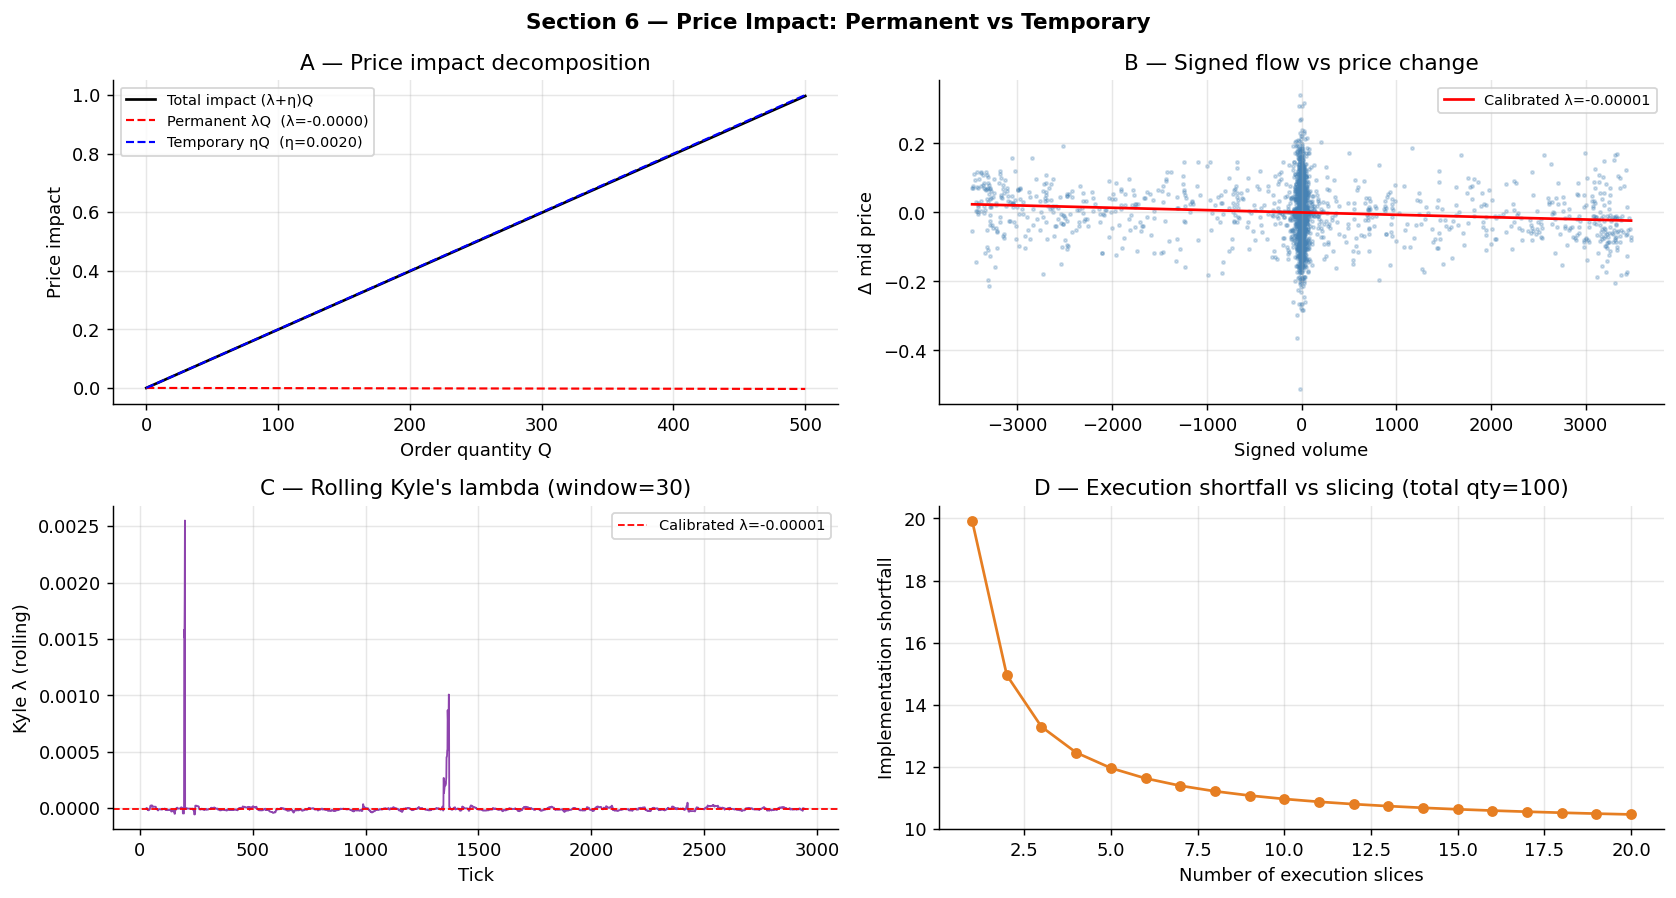

Calibrated Kyle λ  = -0.000007
Temporary impact η = 0.002000
Impact ratio perm/total = -0.3%


In [7]:
model = PriceImpactModel(lambda_=0.001, eta=0.002)

sv    = result.signed_volume()
dp    = np.diff(prices)
n_fit = min(len(sv), len(dp))
model.calibrate(sv[:n_fit], dp[:n_fit])

qty_range = np.linspace(0, 500, 200)
total_imp = [model.total_impact(q, sign=1)     for q in qty_range]
perm_imp  = [model.permanent_impact(q, sign=1) for q in qty_range]
temp_imp  = [model.temporary_impact(q, sign=1) for q in qty_range]

kyle_series = result.kyle_lambda_series(window=30)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

ax = axes[0, 0]
ax.plot(qty_range, total_imp, "k-",  lw=1.5, label="Total impact (λ+η)Q")
ax.plot(qty_range, perm_imp,  "r--", lw=1.2, label=f"Permanent λQ  (λ={model.lambda_:.4f})")
ax.plot(qty_range, temp_imp,  "b--", lw=1.2, label=f"Temporary ηQ  (η={model.eta:.4f})")
ax.set_xlabel("Order quantity Q"); ax.set_ylabel("Price impact")
ax.set_title("A — Price impact decomposition"); ax.legend(fontsize=8)

ax   = axes[0, 1]
clip = np.percentile(np.abs(sv[:n_fit]), 97)
mask = np.abs(sv[:n_fit]) < clip
ax.scatter(sv[:n_fit][mask], dp[:n_fit][mask], s=3, alpha=0.25, color="steelblue")
q_line = np.linspace(sv[:n_fit][mask].min(), sv[:n_fit][mask].max(), 100)
ax.plot(q_line, model.lambda_ * q_line, "r-", lw=1.5,
        label=f"Calibrated λ={model.lambda_:.5f}")
ax.set_xlabel("Signed volume"); ax.set_ylabel("Δ mid price")
ax.set_title("B — Signed flow vs price change"); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(kyle_series, lw=1, color="#8e44ad")
ax.axhline(model.lambda_, ls="--", color="red", lw=1,
           label=f"Calibrated λ={model.lambda_:.5f}")
ax.set_xlabel("Tick"); ax.set_ylabel("Kyle λ (rolling)")
ax.set_title("C — Rolling Kyle's lambda (window=30)"); ax.legend(fontsize=8)

ax = axes[1, 1]
base_qty = 100.0
shortfalls = []
for urgency in range(1, 21):
    q_s = np.full(urgency, base_qty / urgency)
    s_s = np.ones(urgency)
    shortfalls.append(model.execution_shortfall(q_s, s_s, arrival_price=prices[0]))
ax.plot(range(1, 21), shortfalls, "o-", color="#e67e22", ms=5)
ax.set_xlabel("Number of execution slices"); ax.set_ylabel("Implementation shortfall")
ax.set_title(f"D — Execution shortfall vs slicing (total qty={base_qty:.0f})")

plt.suptitle("Section 6 — Price Impact: Permanent vs Temporary", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Calibrated Kyle λ  = {model.lambda_:.6f}")
print(f"Temporary impact η = {model.eta:.6f}")
print(f"Impact ratio perm/total = {model.lambda_/(model.lambda_+model.eta):.1%}")

## 7. Informed vs Noise Trader Flow

**Glosten-Milgrom (1985)** framework: thị trường gồm hai loại trader:

- **Noise trader** (uninformed): giao dịch vì thanh khoản, hedging, hoặc noise. Direction iid random, không liên quan fundamental.
- **Informed trader**: có private signal về $v$ (true value). Giao dịch theo hướng tối đa hóa profit từ thông tin: mua nếu $v > \text{ask}$, bán nếu $v < \text{bid}$.

Market maker không quan sát được trader type, chỉ quan sát order. Expected loss cho MM khi giao dịch với informed trader là **adverse selection cost** — phần chính trong bid-ask spread.

**PIN** ước lượng $\alpha$ (fraction của arriving orders là informed) từ asymmetry giữa buy và sell arrival rates trong ngày có tin tức.

Trong simulation, ta kiểm soát trực tiếp `prob_informed` và `signal_strength`, cho phép:
- So sánh OFI, VPIN, và Kyle λ theo mức độ informed trading
- Quan sát price discovery speed: giá converge về fundamental nhanh hơn khi có nhiều informed trader
- Đo lường adverse selection cost của market maker

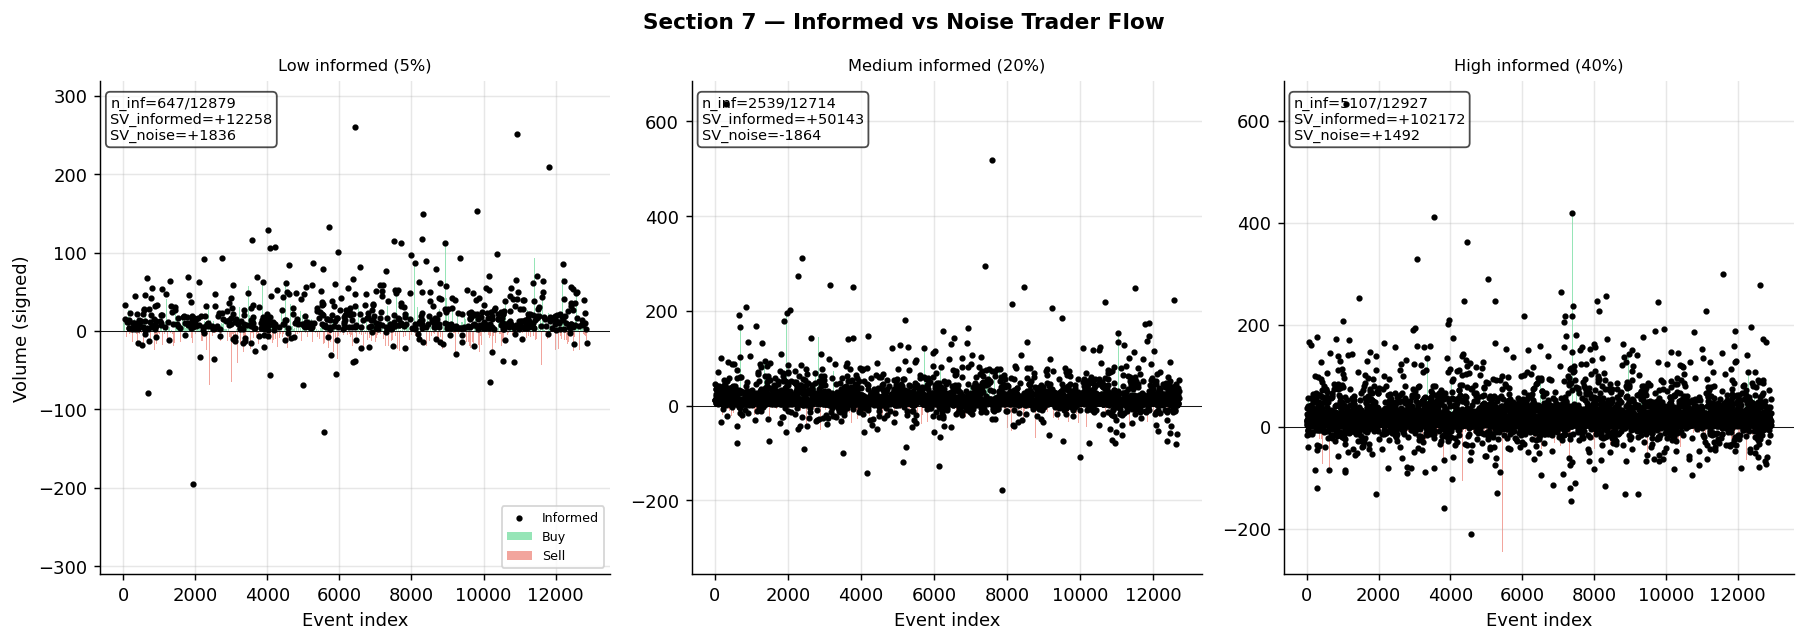


Scenario                      n_inf  n_noise  SV_informed   SV_noise
--------------------------------------------------------------------
Low informed (5%)               647    12232     +12257.5    +1836.1
Medium informed (20%)          2539    10175     +50142.9    -1863.8
High informed (40%)            5107     7820    +102171.8    +1491.8


In [8]:
scenarios = {
    "Low informed (5%)":     dict(prob_informed=0.05, n_steps=800, seed=10),
    "Medium informed (20%)": dict(prob_informed=0.20, n_steps=800, seed=11),
    "High informed (40%)":   dict(prob_informed=0.40, n_steps=800, seed=12),
}

results_inf = {}
for label, cfg in scenarios.items():
    rng_s    = np.random.default_rng(cfg["seed"])
    arrival  = PoissonArrivalProcess(lambda_buy=8.0, lambda_sell=8.0,
                                     dt=1.0, rng=rng_s)
    size_dist = OrderSizeDistribution(rng=np.random.default_rng(cfg["seed"]))
    gen = OrderFlowGenerator(
        prob_informed=cfg["prob_informed"],
        signal_strength=0.80,
        arrival_process=arrival,
        size_dist=size_dist,
        rng=np.random.default_rng(cfg["seed"]),
    )
    gen.update_signal(signal=1)
    events = gen.generate(cfg["n_steps"], mid_price=100.0)

    noise_events    = [e for e in events if e.trader_type == TraderType.NOISE]
    informed_events = [e for e in events if e.trader_type == TraderType.INFORMED]
    noise_sv    = sum(e.quantity if e.side=="bid" else -e.quantity for e in noise_events)
    informed_sv = sum(e.quantity if e.side=="bid" else -e.quantity for e in informed_events)

    results_inf[label] = dict(
        events=events,
        noise_sv=noise_sv, informed_sv=informed_sv,
        n_noise=len(noise_events), n_informed=len(informed_events),
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#3498db", "#e67e22", "#e74c3c"]

for ax, (label, res), color in zip(axes, results_inf.items(), colors):
    events  = res["events"]
    bid_vol = np.array([e.quantity if e.side == "bid" else 0 for e in events])
    ask_vol = np.array([e.quantity if e.side == "ask" else 0 for e in events])
    informed = np.array([1 if e.trader_type == TraderType.INFORMED else 0
                         for e in events])

    ax.bar(range(len(bid_vol)),  bid_vol, color="#2ecc71", alpha=0.5, width=1, label="Buy")
    ax.bar(range(len(ask_vol)), -ask_vol, color="#e74c3c", alpha=0.5, width=1, label="Sell")
    inf_idx  = np.where(informed)[0]
    inf_side = np.array([bid_vol[i] if events[i].side=="bid" else -ask_vol[i]
                         for i in inf_idx])
    ax.scatter(inf_idx, inf_side, s=6, color="black", zorder=5, label="Informed")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(label, fontsize=9); ax.set_xlabel("Event index")
    if ax == axes[0]:
        ax.set_ylabel("Volume (signed)")
        ax.legend(fontsize=7, loc="lower right")

    n_inf = res["n_informed"]; n_tot = len(events)
    ax.text(0.02, 0.97,
            f"n_inf={n_inf}/{n_tot}\n"
            f"SV_informed={res['informed_sv']:+.0f}\n"
            f"SV_noise={res['noise_sv']:+.0f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

plt.suptitle("Section 7 — Informed vs Noise Trader Flow", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'Scenario':<28} {'n_inf':>6} {'n_noise':>8} {'SV_informed':>12} {'SV_noise':>10}")
print("-" * 68)
for label, res in results_inf.items():
    print(f"{label:<28} {res['n_informed']:>6} {res['n_noise']:>8} "
          f"{res['informed_sv']:>+12.1f} {res['noise_sv']:>+10.1f}")

## Tổng kết

| Metric | Đo lường | Notebook tiếp theo |
|---|---|---|
| Hawkes branching ratio $\rho = \alpha/\beta$ | Mức độ clustering của order flow | `07_structural_fragility` |
| OFI | Net queue pressure tại best bid/ask | `03_price_formation` |
| VPIN | Fraction volume từ informed → toxicity | `02_liquidity_and_depth` (spread) |
| Kyle λ | Price impact per unit signed flow | `03_price_formation`, `04_market_maker` |
| Informed fraction | Adverse selection exposure của MM | `04_market_maker_inventory` |

**Key insight:** Ba metrics — OFI, VPIN, Kyle λ — đều phản ánh cùng một hiện tượng từ góc độ khác nhau: sự hiện diện của thông tin trong order flow. Khi informed trading tăng, cả ba đồng thời tăng, và market maker bị buộc phải mở rộng spread để bù đắp adverse selection cost (Notebook 02).